---
# <center>**Taxi Price Prediction**</center>
---

## 1. Create Spark Session

In [1]:
from pyspark.sql import SparkSession

# spark = (
#     SparkSession.builder
#     .appName("Taxi Price Prediction")
#     .config("spark.driver.memory", "4g")
#     .config("spark.executor.memory", "4g")
#     .getOrCreate()
# )
spark = (
    SparkSession.builder
    .appName("Taxi Price Prediction")
    .master("local[*]")
    .config("spark.driver.memory", "4g")   
    .config("spark.driver.maxResultSize", "2g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") 
    .getOrCreate()
)
    
spark.conf.set("spark.sql.files.maxPartitionBytes", "33554432")  # 32 MB

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/06 14:53:17 WARN Utils: Your hostname, Anle-Lenovo, resolves to a loopback address: 127.0.1.1; using 192.168.1.23 instead (on interface wlo1)
26/07/06 14:53:17 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/06 14:53:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


---
## 2. Join Star Schema & Feature Selection

In [2]:
# Load the fact and dimension tables from Parquet files
fact_trips = spark.read.parquet("../data/gold/parquet/fact_trips/")
dim_date = spark.read.parquet("../data/gold/parquet/dim_date/")
dim_vendor = spark.read.parquet("../data/gold/parquet/dim_vendor/")
dim_payment = spark.read.parquet("../data/gold/parquet/dim_payment/")
dim_rate_code = spark.read.parquet("../data/gold/parquet/dim_rate_code/")
print("Load data from Parquet files completed.")

Load data from Parquet files completed.


In [3]:
dims = {
    'dim_date': dim_date,
    'dim_vendor': dim_vendor,
    'dim_payment': dim_payment,
    'dim_rate_code': dim_rate_code,
}

# Fact table
print(f"fact_trips count: {fact_trips.count()}")
fact_trips.show(3, truncate=False)

# Dimension tables
for name, df in dims.items():
    print(f'\n{name}')
    df.show(3, truncate=False)

26/07/06 14:53:26 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


fact_trips count: 47248456
+----------------------------------------------------------------+--------+---------+------------+------------+---------------+-------------------+-----------+------------+--------------+----------+------------+---------------------+------------+-------------------+-------------------+-----------+-----------------+------------------+--------------+------------+------------------+-----------------+------------------+------------------+----+-----+
|trip_id                                                         |date_key|vendor_id|payment_type|rate_code_id|passenger_count|trip_distance_miles|fare_amount|extra_amount|mta_tax_amount|tip_amount|tolls_amount|improvement_surcharge|total_amount|pickup_datetime    |dropoff_datetime   |pickup_hour|duration_minutes |fare_per_mile     |tip_percentage|is_rush_hour|pickup_longitude  |pickup_latitude  |dropoff_longitude |dropoff_latitude  |year|month|
+----------------------------------------------------------------+-------

### 2.1 Join Star Schema

In [4]:
# Join fact table with dimension tables to create a machine learning dataset
ml_df = (
    fact_trips.alias("trip")
    .join(dim_date.alias("date"), on='date_key', how='left')
    .join(dim_vendor.alias("vendor"), on='vendor_id', how='left')
    .join(dim_payment.alias("payment"), on='payment_type', how='left')
    .join(dim_rate_code.alias("rate_code"), on='rate_code_id', how='left')
)
ml_df.show(5, truncate=False)

+------------+------------+---------+--------+----------------------------------------------------------------+---------------+-------------------+-----------+------------+--------------+----------+------------+---------------------+------------+-------------------+-------------------+-----------+------------------+------------------+-----------------+------------+------------------+-----------------+------------------+------------------+----+-----+----------+----+-----+---+-------+-------+----------+------------+------------+--------------+
|rate_code_id|payment_type|vendor_id|date_key|trip_id                                                         |passenger_count|trip_distance_miles|fare_amount|extra_amount|mta_tax_amount|tip_amount|tolls_amount|improvement_surcharge|total_amount|pickup_datetime    |dropoff_datetime   |pickup_hour|duration_minutes  |fare_per_mile     |tip_percentage   |is_rush_hour|pickup_longitude  |pickup_latitude  |dropoff_longitude |dropoff_latitude  |year|month

### 2.2 Feature Selection

In [5]:
from pyspark.sql import functions as F

# Feature selection: select relevant columns for machine learning
ml_df = (
    ml_df
    .select(
        F.col("rate_code_name"), F.col("vendor_name"), F.col("payment_name"),
        F.col("passenger_count"), F.col("trip_distance_miles"), F.col("pickup_hour"), F.col("duration_minutes"),
        F.col("is_rush_hour"), F.col("date.month").alias("month"), F.col("weekday") , F.col("is_weekend"),
        F.col("pickup_latitude"), F.col("pickup_longitude"), F.col("dropoff_latitude"), F.col("dropoff_longitude"),
        F.col("fare_amount")
    )
    .withColumn("is_rush_hour", F.col("is_rush_hour").cast("integer"))
    .withColumn("is_weekend", F.col("is_weekend").cast("integer"))
)

---
## 3. Data Preprocessing

In [6]:
# Data cleaning: filter out invalid or missing data
cleaned_ml_df = (
    ml_df
    .dropna().dropDuplicates()  # Drop Null and duplicate rows
    .filter((F.col("passenger_count") <= 6) & (F.col("passenger_count") >= 1))  # Filter out trips with non-positive passenger count
)

In [7]:
# 1. Lọc các chuyến đi có dữ liệu thực tế
cleaned_ml_df = cleaned_ml_df.filter(
    (F.col("duration_minutes") > 0.5) & (F.col("duration_minutes") < 180) & 
    (F.col("trip_distance_miles") > 0.1) & (F.col("trip_distance_miles") < 100) &
    (F.col("fare_amount") > 2.5) &   # Chi phí mở cửa taxi tối thiểu thường là $2.5
    (F.col("fare_amount") < 500)  # Loại bỏ các chuyến đi có giá quá cao
    
)

# 2. Giới hạn tọa độ địa lý (New York)
cleaned_ml_df = (
    cleaned_ml_df
    .filter((F.col("pickup_latitude").between(40.5, 41.0)) &
    (F.col("pickup_longitude").between(-74.5, -72.5)) &
    (F.col("dropoff_latitude").between(40.5, 41.0)) &
    (F.col("dropoff_longitude").between(-74.5, -72.5))
    )      
)

---
## 4. Feature Engineering

In [8]:
import math

# Feature engieering: Create new features based on existing data
ml_df = (
    cleaned_ml_df
    
    #  Tính khoảng cách Manhattan
    .withColumn(
        "manhattan_dist", 
        F.abs(F.col("dropoff_latitude") - F.col("pickup_latitude")) + 
        F.abs(F.col("dropoff_longitude") - F.col("pickup_longitude")))
    
    # Tính khoảng cách Haversine (Đường chim bay)
    .withColumn("lat1_rad", F.radians(F.col("pickup_latitude")))
    .withColumn("lat2_rad", F.radians(F.col("dropoff_latitude")))
    .withColumn("dlat", F.radians(F.col("dropoff_latitude") - F.col("pickup_latitude")))
    .withColumn("dlon", F.radians(F.col("dropoff_longitude") - F.col("pickup_longitude")))
    .withColumn("haversine_dist", 
        2 * 3956.0 * F.asin(
            F.sqrt(
                F.sin(F.col("dlat") / 2) ** 2 + 
                F.cos(F.col("lat1_rad")) * F.cos(F.col("lat2_rad")) * (F.sin(F.col("dlon") / 2) ** 2)
            )
        )
    )
    # Xóa các cột trung gian vừa tạo
    .drop("lat1_rad", "lat2_rad", "dlat", "dlon")
    
    # Tính tốc độ trung bình (dặm/phút) để phát hiện tắc đường
    .withColumn(
        "est_speed", 
        F.when(F.col("duration_minutes") > 0, F.col("trip_distance_miles") / F.col("duration_minutes"))
        .otherwise(0))
    # Giới hạn tốc độ trung bình thực tế của taxi trong thành phố (ví dụ dưới 80 dặm/giờ ~ 1.33 dặm/phút)
    .filter(F.col("est_speed") < 1.33) 

    # Tạo các biến tuần hoàn từ giờ đón khách (pickup_hour)
    .withColumn(
        "pickup_hour_sin",
        F.sin(2 * F.lit(math.pi) * F.col("pickup_hour") / F.lit(24)),
    )
    .withColumn(
        "pickup_hour_cos",
        F.cos(2 * F.lit(math.pi) * F.col("pickup_hour") / F.lit(24)),
    )
)

In [9]:
import pandas as pd
# df = ml_df.sample(fraction=0.02, seed=42).toPandas()
# df.to_csv("../data/ml_yellow_taxi_dataset.csv", index=False)

df = pd.read_csv("../data/ml_yellow_taxi_dataset.csv")
print(f"ml_df count: {df.shape[0]}")

ml_df count: 919174


## 5. EDA & Data Visualization

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# ====================Config-Visualization===========================


PALETTE = {
    "primary": "#2563EB",      # xanh dương đậm - dùng cho biến chính (fare_amount)
    "secondary": "#F97316",    # cam - dùng cho biến phụ
    "accent": "#10B981",       # xanh lá - dùng cho highlight / best model
    "muted": "#94A3B8",        # xám - dùng cho gridline, phụ trợ
    "warning": "#EF4444",      # đỏ - dùng cho outlier / cảnh báo
}
SEQUENTIAL_CMAP = "Blues"
CATEGORICAL_PALETTE = ["#2563EB", "#F97316", "#10B981", "#A855F7", "#EAB308"]

SAMPLE_FRACTION = 0.002
RANDOM_STATE = 42

def setup_plot_style():
    """Thiết lập style biểu đồ nhất quán, hiện đại cho toàn bộ notebook."""
    sns.set_theme(style="white", context="notebook")
    plt.rcParams.update({
        "figure.figsize": (12, 6),
        "figure.dpi": 110,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "axes.edgecolor": "#CBD5E1",
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "grid.color": "#E2E8F0",
        "grid.linewidth": 0.6,
        "grid.alpha": 0.7,
        "font.family": "DejaVu Sans",
        "text.color": "#1E293B",
        "axes.labelcolor": "#334155",
        "xtick.color": "#475569",
        "ytick.color": "#475569",
        "legend.frameon": False,
    })
    pd.set_option("display.max_columns", None)
    pd.set_option("display.float_format", lambda value: f"{value:,.3f}")


def style_axis(ax, title=None, xlabel=None, ylabel=None):
    """Áp style chung (bỏ spine thừa, format title/label) cho một axis."""
    if title:
        ax.set_title(title, pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.5)
    return ax


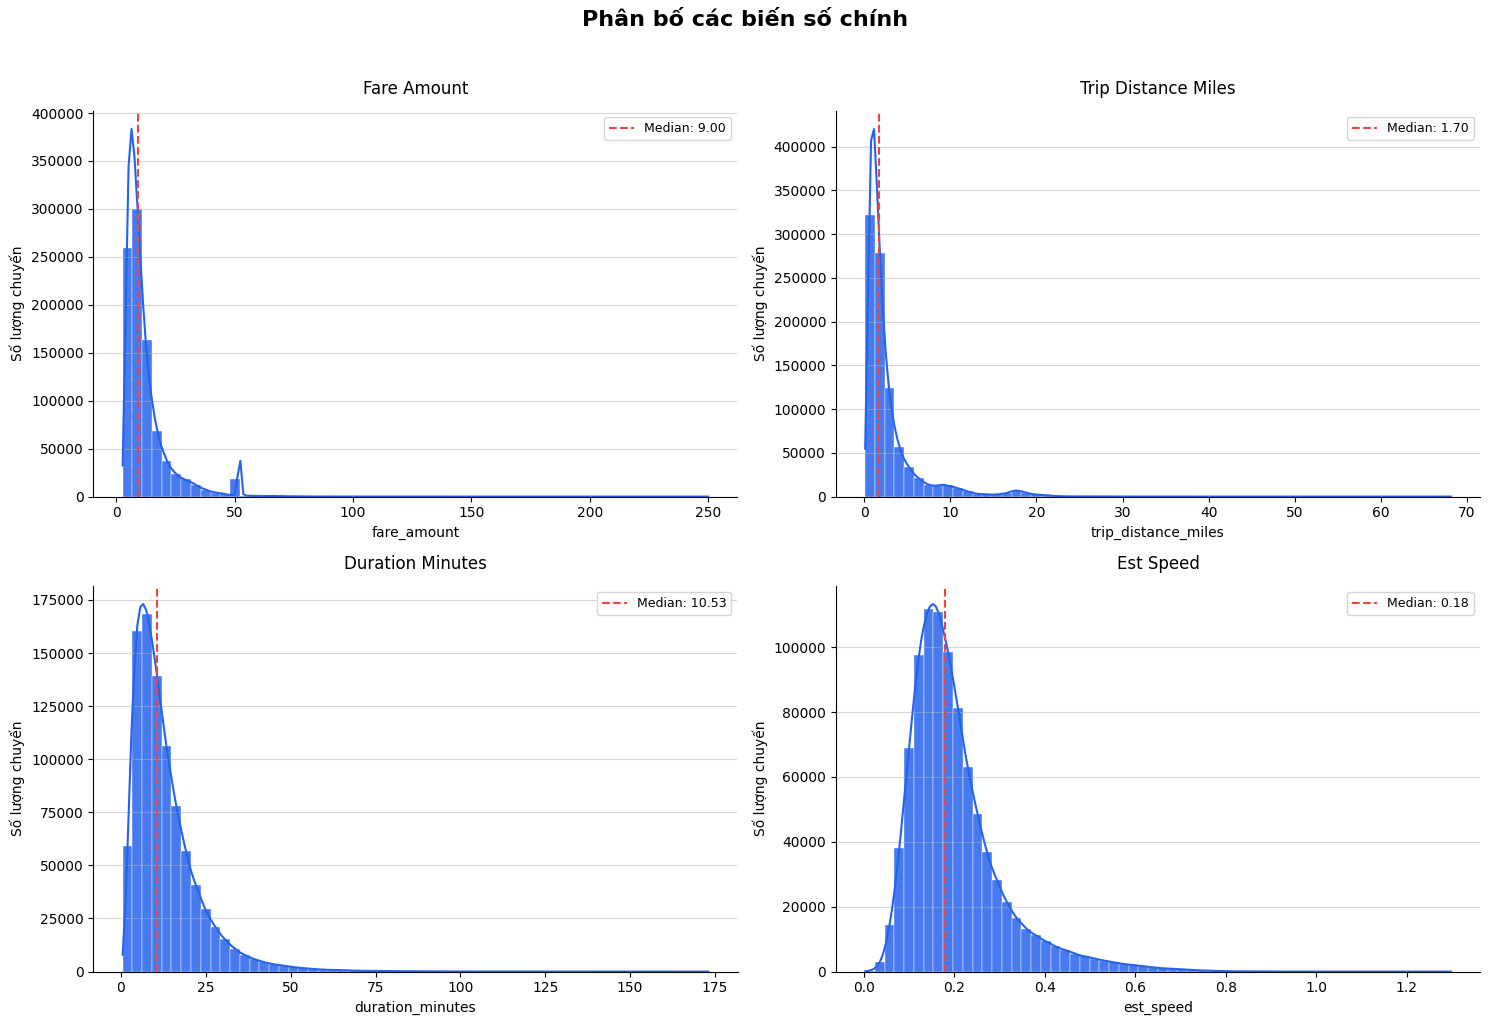

In [12]:
def plot_distributions(pdf, columns=("fare_amount", "trip_distance_miles",
                                      "duration_minutes", "est_speed")):
    """Histogram + KDE cho label và các biến số quan trọng, 2x2 grid."""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle("Phân bố các biến số chính", fontsize=16, fontweight="bold", y=1.02)

    for axis, column in zip(axes.flatten(), columns):
        data = pdf[column].dropna()
        sns.histplot(
            data, bins=60, kde=True, ax=axis,
            color=PALETTE["primary"], edgecolor="white", linewidth=0.3,
            alpha=0.85,
        )
        median_val = data.median()
        axis.axvline(median_val, color=PALETTE["warning"], linestyle="--", linewidth=1.5,
                      label=f"Median: {median_val:,.2f}")
        axis.legend(loc="upper right", fontsize=9)
        style_axis(axis, title=column.replace("_", " ").title(), xlabel=column, ylabel="Số lượng chuyến")

    plt.tight_layout()
    plt.show()
    
plot_distributions(df)

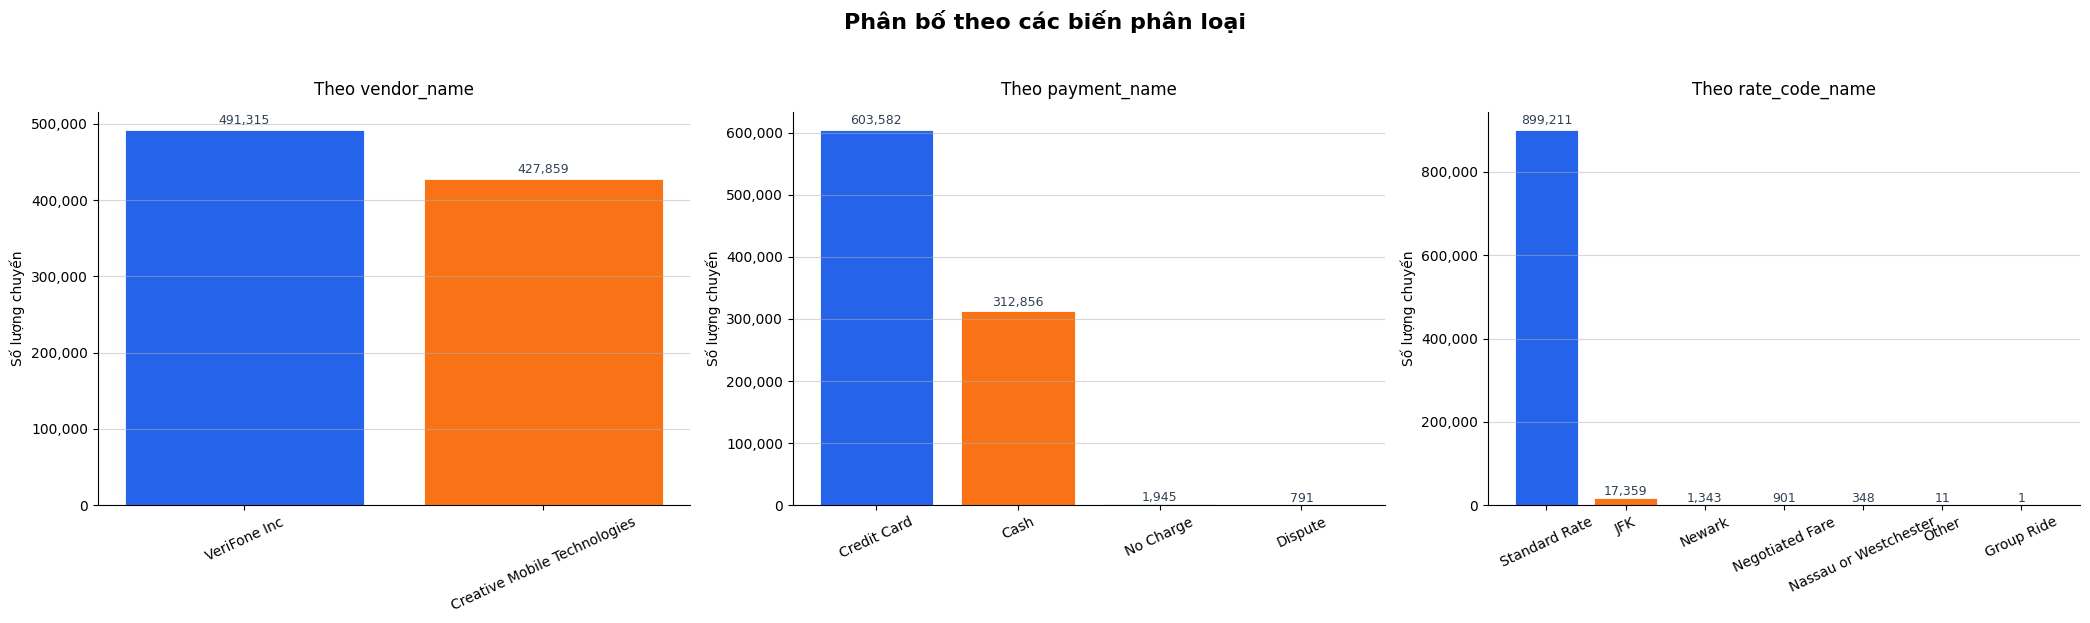

In [13]:
import numpy as np
import matplotlib.ticker as mticker

def plot_category_balance(pdf, columns=("vendor_name", "payment_name", "rate_code_name")):
    """Bar chart phân bố số lượng theo các biến phân loại, có annotation số liệu."""
    available_cols = [c for c in columns if c in pdf.columns]
    fig, axes = plt.subplots(1, len(available_cols), figsize=(7 * len(available_cols), 6))
    fig.suptitle("Phân bố theo các biến phân loại", fontsize=16, fontweight="bold", y=1.03)

    if len(available_cols) == 1:
        axes = [axes]

    for axis, column in zip(axes, available_cols):
        counts = pdf[column].fillna("Unknown").value_counts()
        bars = axis.bar(
            counts.index.astype(str), counts.values,
            color=CATEGORICAL_PALETTE[: len(counts)],
            edgecolor="white", linewidth=0.6,
        )
        for bar in bars:
            height = bar.get_height()
            axis.text(
                bar.get_x() + bar.get_width() / 2, height + height * 0.01,
                f"{int(height):,}", ha="center", va="bottom", fontsize=9, color="#334155",
            )
        axis.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
        style_axis(axis, title=f"Theo {column}", xlabel="", ylabel="Số lượng chuyến")
        axis.tick_params(axis="x", rotation=25)

    plt.tight_layout()
    plt.show()
    
plot_category_balance(df)

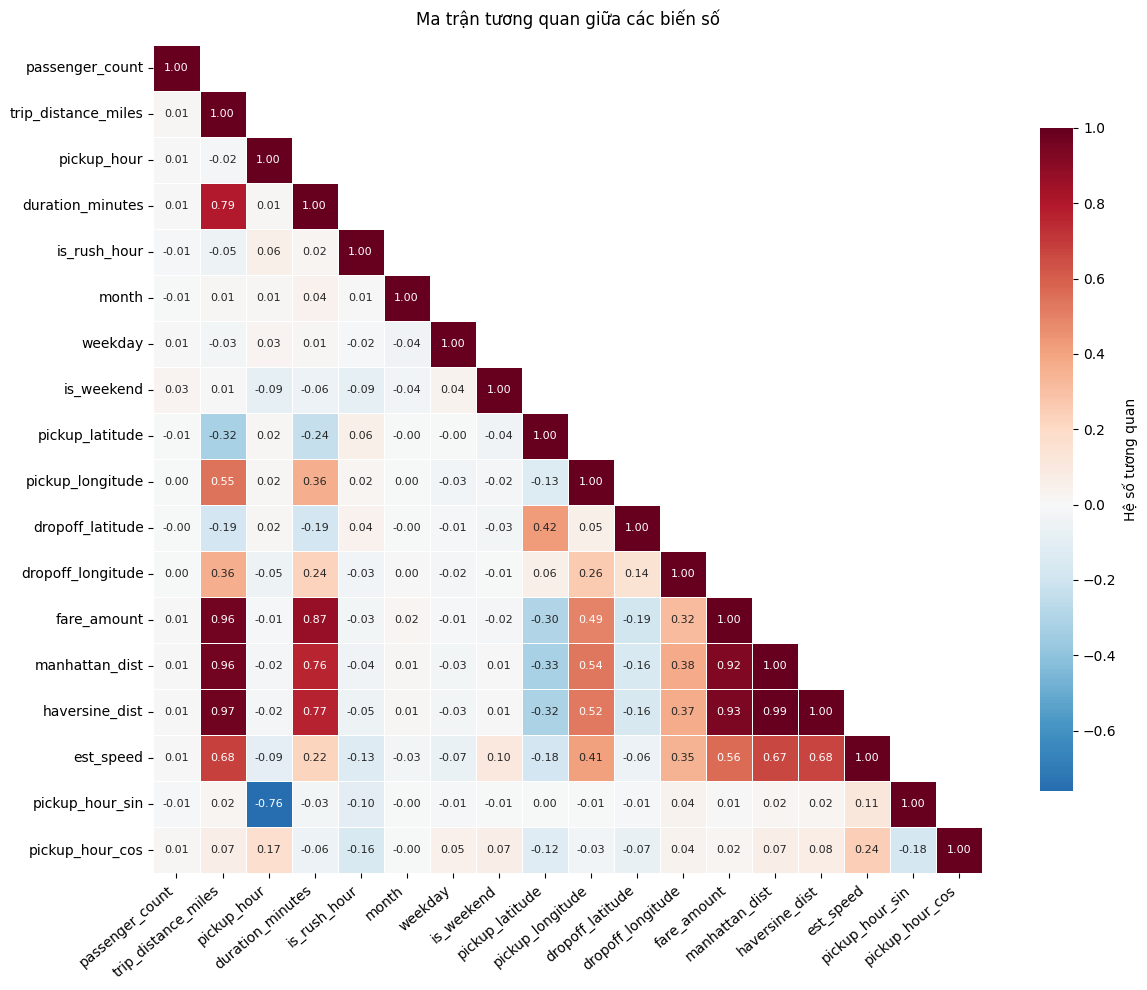

In [14]:
def plot_correlation_heatmap(pdf, correlation_cols):
    """Heatmap tương quan, chỉ hiển thị nửa tam giác dưới, có annotation giá trị."""
    cols = [c for c in correlation_cols if c in pdf.columns]
    corr_matrix = pdf[cols].corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

    plt.figure(figsize=(13, 10))
    sns.heatmap(
        corr_matrix, mask=mask, cmap="RdBu_r", center=0,
        annot=True, fmt=".2f", annot_kws={"size": 8},
        square=True, linewidths=0.5, linecolor="white",
        cbar_kws={"label": "Hệ số tương quan", "shrink": 0.8},
    )
    plt.title("Ma trận tương quan giữa các biến số", pad=14)
    plt.xticks(rotation=40, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

num_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
plot_correlation_heatmap(df, correlation_cols=num_cols)

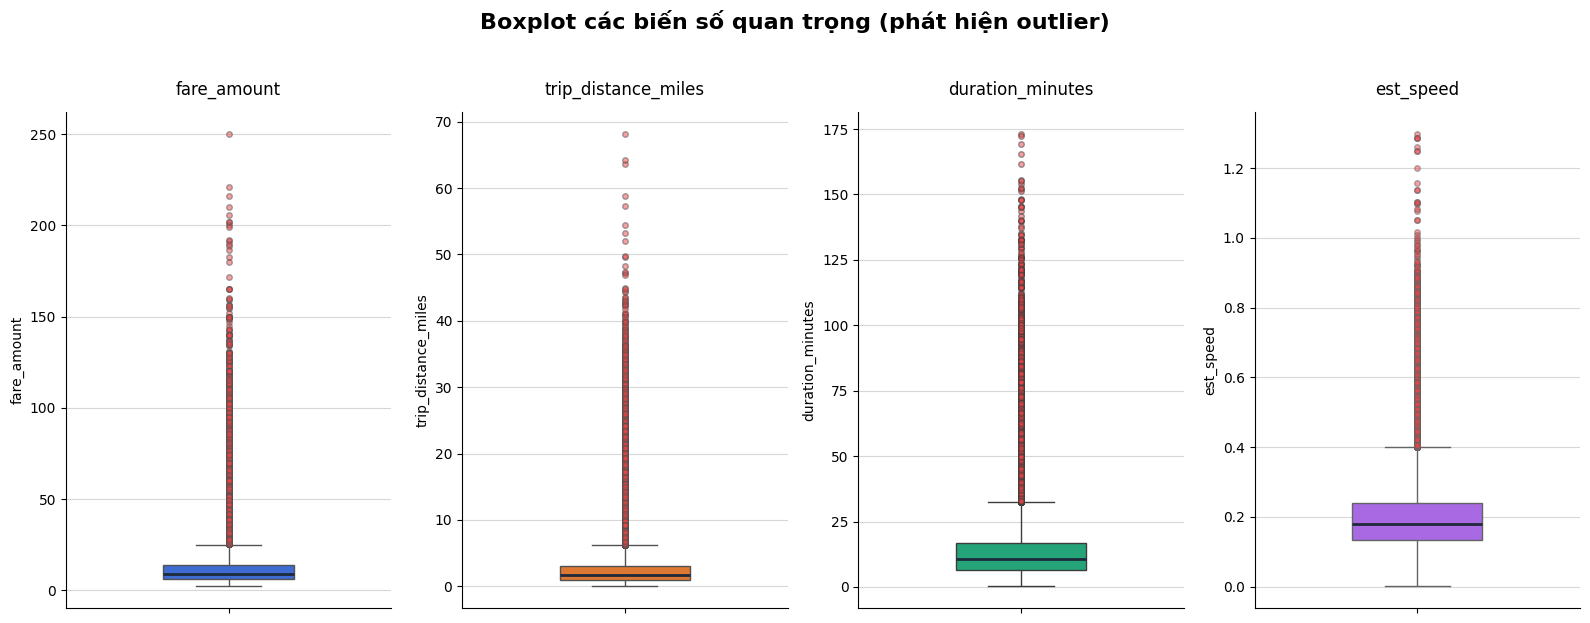

In [15]:
def plot_boxplots(pdf, columns=("fare_amount", "trip_distance_miles", "duration_minutes", "est_speed")):
    """Boxplot để làm rõ outlier, mỗi biến một subplot riêng (tránh lệch scale)."""
    fig, axes = plt.subplots(1, len(columns), figsize=(4 * len(columns), 6))
    fig.suptitle("Boxplot các biến số quan trọng (phát hiện outlier)", fontsize=16, fontweight="bold", y=1.03)

    for axis, column, color in zip(axes, columns, CATEGORICAL_PALETTE):
        sns.boxplot(
            y=pdf[column], ax=axis, color=color, width=0.4,
            flierprops={"markerfacecolor": PALETTE["warning"], "markersize": 4, "alpha": 0.5},
            medianprops={"color": "#1E293B", "linewidth": 2},
        )
        style_axis(axis, title=column, ylabel=column, xlabel="")

    plt.tight_layout()
    plt.show()

plot_boxplots(df)

In [ ]:
# Remove outliers using IQR method in Spark DataFrame
def remove_outliers_iqr_spark(df, columns, contamination=1.5):
    for col in columns:
        # approxQuantile nhanh hơn exact, đủ dùng cho outlier detection
        Q1, Q3 = df.approxQuantile(col, [0.25, 0.75], relativeError=0.01)
        IQR = Q3 - Q1
        lower = Q1 - contamination * IQR
        upper = Q3 + contamination * IQR
        
        print(f"{col}: giữ [{lower:.2f}, {upper:.2f}]")
        df = df.filter(F.col(col).between(lower, upper))
    
    return df

ml_df = remove_outliers_iqr_spark(ml_df, columns=["fare_amount", "trip_distance_miles", "manhattan_dist", "haversine_dist", "duration_minutes", "est_speed"], contamination=1.5)

fare_amount: giữ [-4.75, 25.25]


trip_distance_miles: giữ [-1.53, 5.08]


manhattan_dist: giữ [-0.02, 0.07]


haversine_dist: giữ [-0.79, 3.17]


---
## 6. Modeling


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [18]:
ml_df = (
    ml_df.select(
        "trip_distance_miles", "pickup_latitude",
        "pickup_longitude", "dropoff_latitude", "dropoff_longitude", 
        "manhattan_dist", "haversine_dist",
        "rate_code_name", "vendor_name", "weekday", "fare_amount"
    ).sample(withReplacement=False, fraction=0.05, seed=42)
)
df = ml_df.toPandas()
print(len(df))

1886177


In [19]:
# def remove_outliers_iqr(pdf, columns, contamination=1.5):
#     """Remove outliers using IQR method for pandas DataFrame."""
#     df_cleaned = pdf.copy()
    
#     for col in columns:
#         Q1 = df_cleaned[col].quantile(0.25)
#         Q3 = df_cleaned[col].quantile(0.75)
#         IQR = Q3 - Q1
#         lower = Q1 - contamination * IQR
#         upper = Q3 + contamination * IQR
        
#         print(f"{col}: giữ [{lower:.2f}, {upper:.2f}]")
#         df_cleaned = df_cleaned[(df_cleaned[col] >= lower) & (df_cleaned[col] <= upper)]
    
#     return df_cleaned

# df = remove_outliers_iqr(df, columns=["fare_amount", "trip_distance_miles", "duration_minutes", "est_speed", "manhattan_dist", "haversine_dist"], contamination=1.5)

In [ ]:
# Feature for models
FEATURE_NUMERIC_COLS = [
    "trip_distance_miles", "pickup_latitude",
    "pickup_longitude", "dropoff_latitude", "dropoff_longitude", 
    "manhattan_dist", "haversine_dist", "duration_minutes", "est_speed"
]

FEATURE_CATEGORICAL_COLS = [
    "rate_code_name", "vendor_name", "weekday", 
]

### 6.1 Split Dataset

In [21]:
X = df[FEATURE_NUMERIC_COLS + FEATURE_CATEGORICAL_COLS]  # Feature
y = df["fare_amount"] # Label

# Split dataset
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

### 6.2 Encoder

In [22]:
def build_pipeline(model, FEATURE_NUMERIC_COLS, FEATURE_CATEGORICAL_COLS, scale_numeric=False):
    preprocessor = ColumnTransformer([
        ("num", StandardScaler() if scale_numeric else "passthrough", FEATURE_NUMERIC_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURE_CATEGORICAL_COLS),
    ])
    
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    
    return pipeline

In [23]:
def train_models(
    *,
    models,
    X_train,
    y_train,
):
    """Train tất cả các mô hình."""

    trained_models = {}

    for model_name, pipeline in models.items():
        print(f"Training {model_name}...")

        pipeline.fit(
            X=X_train,
            y=y_train,
        )

        trained_models[model_name] = pipeline

    return trained_models

In [24]:
def evaluate_models(
    *,
    trained_models,
    X_test,
    y_test,
):
    """Đánh giá các mô hình đã train và trả về DataFrame."""

    evaluation_results = []

    for model_name, pipeline in trained_models.items():

        y_pred = pipeline.predict(X=X_test)

        mse = mean_squared_error(
            y_true=y_test,
            y_pred=y_pred,
        )

        evaluation_results.append({
            "Model": model_name,
            "MSE": mse,
            "RMSE": np.sqrt(mse),
            "MAE": mean_absolute_error(
                y_true=y_test,
                y_pred=y_pred,
            ),
            "R2": r2_score(
                y_true=y_test,
                y_pred=y_pred,
            ),
        })

    evaluation_df = (
        pd.DataFrame(evaluation_results)
        .sort_values(
            by="R2",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    return evaluation_df

### 6.3 Training & Evaluate

In [25]:
# Linear Regression
lr_pipeline = build_pipeline(LinearRegression(), FEATURE_NUMERIC_COLS, FEATURE_CATEGORICAL_COLS, scale_numeric=True)

# Random Forest
rtf_pipeline = build_pipeline(RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=2, random_state=42, n_jobs=-1), FEATURE_NUMERIC_COLS, FEATURE_CATEGORICAL_COLS, scale_numeric=False)

# Gradient Boosting
gbr_pipeline = build_pipeline(GradientBoostingRegressor(n_estimators=100, random_state=42), FEATURE_NUMERIC_COLS, FEATURE_CATEGORICAL_COLS, scale_numeric=False)

In [26]:
models = {
    "Linear Regression": lr_pipeline,
    "Random Forest": rtf_pipeline,
    "Gradient Boosting": gbr_pipeline,
}

# Training
trained_models = train_models(
    models=models,
    X_train=X_train,
    y_train=y_train,
)

# Evaluation
evaluation_df = evaluate_models(
    trained_models=trained_models,
    X_test=X_test,
    y_test=y_test,
)

display(evaluation_df)

Training Linear Regression...
Training Random Forest...
Training Gradient Boosting...


,Model,MSE,RMSE,MAE,R2
0,Gradient Boosting,2.426626,1.557763,1.102521,0.808409
1,Random Forest,2.437806,1.561347,1.100569,0.807526
2,Linear Regression,2.678847,1.636718,1.167031,0.788495


### 6.4 Save Model

In [27]:
import joblib

# Save the best model (Gradient Boosting) to a file
gbt_model = models["Gradient Boosting"]
joblib.dump(gbt_model, '../models/gradient_boosting_model_v3.pkl', compress=3)
    
rft_model = models["Random Forest"]
joblib.dump(rft_model, '../models/random_forest_model_v3.pkl', compress=3)

['../models/random_forest_model_v3.pkl']

In [28]:
def plot_model_comparison(comparison_df):
    """Vẽ biểu đồ so sánh MSE, RMSE, MAE và R2 giữa các mô hình."""

    metrics = ["MSE", "RMSE", "MAE", "R2"]

    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(14, 10),
    )

    axes = axes.flatten()

    for ax, metric in zip(axes, metrics):

        # Xác định mô hình tốt nhất
        if metric == "R2":
            best_idx = comparison_df[metric].idxmax()
            ylabel = "Higher is better"
        else:
            best_idx = comparison_df[metric].idxmin()
            ylabel = "Lower is better"

        colors = [
            PALETTE["accent"] if idx == best_idx else PALETTE["muted"]
            for idx in comparison_df.index
        ]

        bars = ax.bar(
            comparison_df["Model"],
            comparison_df[metric],
            color=colors,
            edgecolor="white",
            linewidth=0.8,
        )

        # Hiển thị giá trị trên cột
        for bar, value in zip(bars, comparison_df[metric]):
            ax.text(
                x=bar.get_x() + bar.get_width() / 2,
                y=bar.get_height(),
                s=f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
            )

        style_axis(
            ax=ax,
            title=f"{metric} Comparison",
            xlabel="",
            ylabel=ylabel,
        )

    plt.suptitle(
        "Model Performance Comparison",
        fontsize=18,
        fontweight="bold",
    )

    plt.tight_layout()
    plt.show()

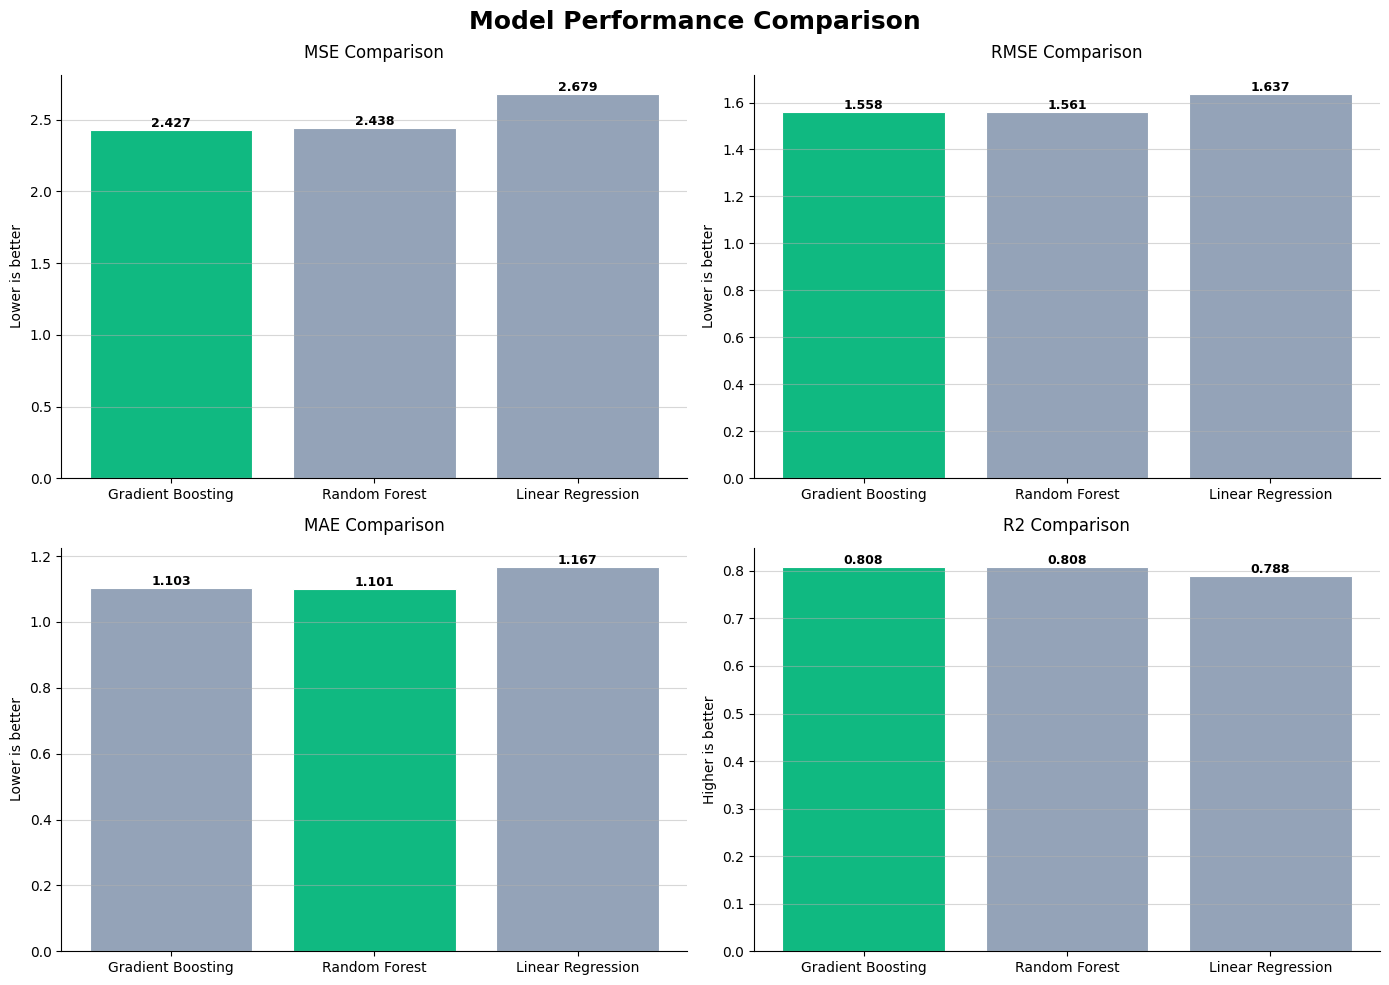

In [29]:
plot_model_comparison(evaluation_df)